In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from pathlib import Path

In [95]:
path_dir = Path(".")

In [96]:
path_dir.resolve()

WindowsPath('C:/Users/Shaaf/Desktop/Data Science/Practice Projects/DeepLearning/Energy Predictions')

In [97]:
data_path = path_dir/"Data/household_energy_consumption.csv"

In [98]:
data_path.resolve()

WindowsPath('C:/Users/Shaaf/Desktop/Data Science/Practice Projects/DeepLearning/Energy Predictions/Data/household_energy_consumption.csv')

In [99]:
df_raw=pd.read_csv(data_path,parse_dates=['Date'])

In [100]:
df_raw

,Unnamed: 0,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C_x,Has_AC,Peak_Hours_Usage_kWh,Avg_Temperature_C_y,Avg_Humidity_Pct,Day,Month,Is Weekend,Is_Holiday
0,0,2025-04-01,8.4,4,17.8,0,3.2,12.0,80,5,1,1,0
1,1,2025-04-01,17.8,5,20.1,1,7.8,12.0,80,5,1,1,0
2,2,2025-04-01,9.0,3,12.7,0,3.1,12.0,80,5,1,1,0
3,3,2025-04-01,15.2,5,15.1,1,7.2,12.0,80,5,1,1,0
4,4,2025-04-01,5.6,2,21.9,0,1.8,12.0,80,5,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80869,80869,2025-04-07,14.5,4,14.9,1,6.4,19.6,75,4,7,0,1
80870,80870,2025-04-07,20.0,5,17.5,1,8.1,19.6,75,4,7,0,1
80871,80871,2025-04-07,14.0,4,16.9,1,6.3,19.6,75,4,7,0,1
80872,80872,2025-04-07,15.3,4,18.2,1,6.6,19.6,75,4,7,0,1


In [101]:
df_raw['Has_AC'].value_counts()

Has_AC
0    40932
1    39942
Name: count, dtype: int64

In [9]:
df_raw['Has_AC']=df_raw['Has_AC'].astype(int)

In [10]:
# df_raw['Has_AC']=df_raw['Has_AC'].apply(lambda x:1 if x=="Yes" else 0)

In [102]:
df_raw

,Unnamed: 0,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C_x,Has_AC,Peak_Hours_Usage_kWh,Avg_Temperature_C_y,Avg_Humidity_Pct,Day,Month,Is Weekend,Is_Holiday
0,0,2025-04-01,8.4,4,17.8,0,3.2,12.0,80,5,1,1,0
1,1,2025-04-01,17.8,5,20.1,1,7.8,12.0,80,5,1,1,0
2,2,2025-04-01,9.0,3,12.7,0,3.1,12.0,80,5,1,1,0
3,3,2025-04-01,15.2,5,15.1,1,7.2,12.0,80,5,1,1,0
4,4,2025-04-01,5.6,2,21.9,0,1.8,12.0,80,5,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80869,80869,2025-04-07,14.5,4,14.9,1,6.4,19.6,75,4,7,0,1
80870,80870,2025-04-07,20.0,5,17.5,1,8.1,19.6,75,4,7,0,1
80871,80871,2025-04-07,14.0,4,16.9,1,6.3,19.6,75,4,7,0,1
80872,80872,2025-04-07,15.3,4,18.2,1,6.6,19.6,75,4,7,0,1


In [12]:
df_raw['Has_AC'].value_counts()

Has_AC
0    40932
1    39942
Name: count, dtype: int64

In [13]:
a =df_raw.groupby('Household_Size')['Energy_Consumption_kWh'].sum()

<Axes: xlabel='Household_Size'>

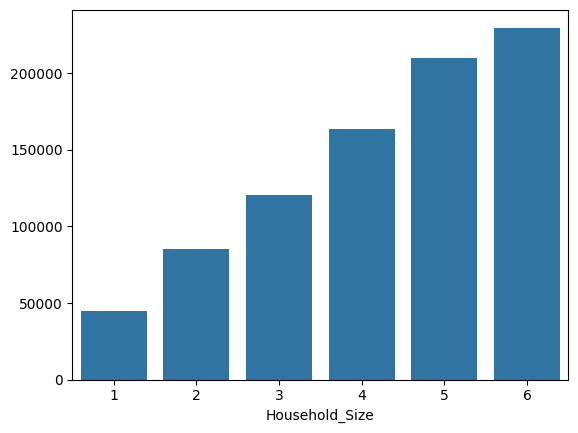

In [14]:
sns.barplot(x=a.index,y=a.values)

In [15]:
print(pd.infer_freq(df_raw['Date']))

None


In [16]:
print(f"Date Start {df_raw['Date'].min()}")
print(f"Date Ends {df_raw['Date'].max()}")
      

Date Start 2025-04-01 00:00:00
Date Ends 2025-04-07 00:00:00


In [17]:
start_date = df_raw['Date'].min()
end_data = df_raw['Date'].max()

In [18]:
# import requests
# import pandas as pd

# # CONFIGURATION
# # Location: San Diego, CA
# LATITUDE = 32.7157
# LONGITUDE = -117.1611

# url = (
#     f"https://archive-api.open-meteo.com/v1/archive?"
#     f"latitude={LATITUDE}"
#     f"&longitude={LONGITUDE}"
#     f"&start_date=2024-03-01"
#     f"&end_date=2026-01-01"
#     f"&daily=temperature_2m_mean,relative_humidity_2m_mean"
#     f"&timezone=auto"
# )

# response = requests.get(url)
# data = response.json()

# weather_df = pd.DataFrame({
#     "Date": data["daily"]["time"],
#     "Avg_Temperature_C": data["daily"]["temperature_2m_mean"],
#     "Avg_Humidity_Pct": data["daily"]["relative_humidity_2m_mean"]
# })

# print(weather_df.head())

# weather_df.to_csv("weather_data.csv", index=False)

In [19]:
weather_df=pd.read_csv(path_dir/'weather_data.csv')

In [20]:
weather_df['Date']=pd.to_datetime(weather_df['Date'])

In [21]:
df_new = df_raw.copy()

In [22]:
df_raw

,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C_x,Has_AC,Peak_Hours_Usage_kWh,Avg_Temperature_C_y,Avg_Humidity_Pct,Day,Month,Is Weekend,Is_Holiday
0,2025-04-01,8.4,4,17.8,0,3.2,12.0,80,5,1,1,0
1,2025-04-01,17.8,5,20.1,1,7.8,12.0,80,5,1,1,0
2,2025-04-01,9.0,3,12.7,0,3.1,12.0,80,5,1,1,0
3,2025-04-01,15.2,5,15.1,1,7.2,12.0,80,5,1,1,0
4,2025-04-01,5.6,2,21.9,0,1.8,12.0,80,5,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
80869,2025-04-07,14.5,4,14.9,1,6.4,19.6,75,4,7,0,1
80870,2025-04-07,20.0,5,17.5,1,8.1,19.6,75,4,7,0,1
80871,2025-04-07,14.0,4,16.9,1,6.3,19.6,75,4,7,0,1
80872,2025-04-07,15.3,4,18.2,1,6.6,19.6,75,4,7,0,1


In [23]:
# df_new=df_new.merge(weather_df,on='Date', how='left')

In [24]:
df_new.to_csv(data_path)

In [25]:
df_raw['Avg_Humidity_Pct'].isnull().sum()

np.int64(0)

In [26]:
# df_new['Avg_Humidity_Pct'].interpolate(inplace=True)

In [27]:
# df_new.drop('Household_ID',inplace=True,axis=1)

In [28]:
df_new=df_raw.copy()

In [29]:
df_new['Avg_Humidity_Pct'].isnull().sum()

np.int64(0)

In [104]:
df_new

,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C_x,Has_AC,Peak_Hours_Usage_kWh,Avg_Temperature_C_y,Avg_Humidity_Pct,Day,Month,Is Weekend,Is_Holiday
0,2025-04-01,8.4,4,17.8,0,3.2,12.0,80,1,4,0,0
8565,2025-04-01,7.6,3,18.2,0,2.7,12.0,80,1,4,0,0
8566,2025-04-01,18.8,5,16.8,1,7.8,12.0,80,1,4,0,0
8567,2025-04-01,12.0,5,14.7,0,3.8,12.0,80,1,4,0,0
8568,2025-04-01,4.4,2,15.9,0,1.5,12.0,80,1,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
78389,2025-04-07,7.4,3,14.7,0,2.8,19.6,75,0,4,0,0
78390,2025-04-07,5.9,2,14.2,0,2.1,19.6,75,0,4,0,0
78391,2025-04-07,15.1,6,18.1,0,5.9,19.6,75,0,4,0,0
78379,2025-04-07,7.0,3,17.8,0,2.5,19.6,75,0,4,0,0


In [105]:
df_new['Day'] = df_new['Date'].dt.day_of_week
df_new['Month'] =df_new['Date'].dt.month
df_new['Is Weekend'] =df_new['Date'].dt.day_of_week.apply(lambda x:1 if x>=5 else 0)

In [32]:
import holidays

In [33]:
us_holidays=holidays.US()

In [107]:
df_new['Is_Holiday']=df_new['Date'].apply(lambda x:1 if x in us_holidays else 0)

In [106]:
df_new

,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C_x,Has_AC,Peak_Hours_Usage_kWh,Avg_Temperature_C_y,Avg_Humidity_Pct,Day,Month,Is Weekend,Is_Holiday
0,2025-04-01,8.4,4,17.8,0,3.2,12.0,80,1,4,0,0
8565,2025-04-01,7.6,3,18.2,0,2.7,12.0,80,1,4,0,0
8566,2025-04-01,18.8,5,16.8,1,7.8,12.0,80,1,4,0,0
8567,2025-04-01,12.0,5,14.7,0,3.8,12.0,80,1,4,0,0
8568,2025-04-01,4.4,2,15.9,0,1.5,12.0,80,1,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
78389,2025-04-07,7.4,3,14.7,0,2.8,19.6,75,0,4,0,0
78390,2025-04-07,5.9,2,14.2,0,2.1,19.6,75,0,4,0,0
78391,2025-04-07,15.1,6,18.1,0,5.9,19.6,75,0,4,0,0
78379,2025-04-07,7.0,3,17.8,0,2.5,19.6,75,0,4,0,0


In [36]:
df_new[['Energy_Consumption_kWh',
    'Peak_Hours_Usage_kWh']].describe()

,Energy_Consumption_kWh,Peak_Hours_Usage_kWh
count,80874.000000,80874.000000
mean,10.567337,4.317391
std,5.521481,2.532172
min,0.500000,0.200000
25%,6.000000,2.300000
50%,10.300000,4.000000
75%,14.800000,6.000000
max,20.000000,10.000000


In [37]:
df_new[['Energy_Consumption_kWh',
    'Peak_Hours_Usage_kWh']].corr()

,Energy_Consumption_kWh,Peak_Hours_Usage_kWh
Energy_Consumption_kWh,1.000000,0.967645
Peak_Hours_Usage_kWh,0.967645,1.000000


In [38]:
df_new.columns

Index(['Date', 'Energy_Consumption_kWh', 'Household_Size',
       'Avg_Temperature_C_x', 'Has_AC', 'Peak_Hours_Usage_kWh',
       'Avg_Temperature_C_y', 'Avg_Humidity_Pct', 'Day', 'Month', 'Is Weekend',
       'Is_Holiday'],
      dtype='object')

In [39]:
df_new[['Avg_Temperature_C_x',
    'Avg_Temperature_C_y']].corr()

,Avg_Temperature_C_x,Avg_Temperature_C_y
Avg_Temperature_C_x,1.000000,-0.003765
Avg_Temperature_C_y,-0.003765,1.000000


In [40]:
corr = df_new.corr(numeric_only=True)

corr['Energy_Consumption_kWh'].sort_values(ascending=False)

Energy_Consumption_kWh    1.000000
Peak_Hours_Usage_kWh      0.967645
Household_Size            0.894059
Has_AC                    0.347633
Avg_Temperature_C_x       0.033378
Day                       0.000566
Avg_Humidity_Pct          0.000404
Is Weekend               -0.000391
Avg_Temperature_C_y      -0.002925
Month                          NaN
Is_Holiday                     NaN
Name: Energy_Consumption_kWh, dtype: float64

In [41]:
df_new.isnull().sum()

Date                      0
Energy_Consumption_kWh    0
Household_Size            0
Avg_Temperature_C_x       0
Has_AC                    0
Peak_Hours_Usage_kWh      0
Avg_Temperature_C_y       0
Avg_Humidity_Pct          0
Day                       0
Month                     0
Is Weekend                0
Is_Holiday                0
dtype: int64

In [42]:
df_new.dtypes

Date                      datetime64[ns]
Energy_Consumption_kWh           float64
Household_Size                     int64
Avg_Temperature_C_x              float64
Has_AC                             int64
Peak_Hours_Usage_kWh             float64
Avg_Temperature_C_y              float64
Avg_Humidity_Pct                   int64
Day                                int32
Month                              int32
Is Weekend                         int64
Is_Holiday                         int64
dtype: object

In [43]:
# for i in df_new.columns:
#     sns.boxplot(df_new[i])
#     plt.show()

In [46]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [47]:
df_new.columns

Index(['Date', 'Energy_Consumption_kWh', 'Household_Size',
       'Avg_Temperature_C_x', 'Has_AC', 'Peak_Hours_Usage_kWh',
       'Avg_Temperature_C_y', 'Avg_Humidity_Pct', 'Day', 'Month', 'Is Weekend',
       'Is_Holiday'],
      dtype='object')

In [48]:
df_new.sort_values(by='Date',inplace=True)

In [49]:
features = df_new.drop(['Date','Energy_Consumption_kWh','Peak_Hours_Usage_kWh','Avg_Temperature_C_x'],axis=1)

In [50]:
features

,Household_Size,Has_AC,Avg_Temperature_C_y,Avg_Humidity_Pct,Day,Month,Is Weekend,Is_Holiday
0,4,0,12.0,80,1,4,0,0
8565,3,0,12.0,80,1,4,0,0
8566,5,1,12.0,80,1,4,0,0
8567,5,0,12.0,80,1,4,0,0
8568,2,0,12.0,80,1,4,0,0
...,...,...,...,...,...,...,...,...
78389,3,0,19.6,75,0,4,0,0
78390,2,0,19.6,75,0,4,0,0
78391,6,0,19.6,75,0,4,0,0
78379,3,0,19.6,75,0,4,0,0


In [51]:
target = df_new['Peak_Hours_Usage_kWh']

In [52]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
# features = features.sort_values('Date')
target = target.loc[features.index]

split_idx = int(len(features) * 0.8)

X_train = features.iloc[:split_idx]
X_test  = features.iloc[split_idx:]

y_train = target.iloc[:split_idx]
y_test  = target.iloc[split_idx:]

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRFRegressor
scalar=StandardScaler()
# X_train = pd.DataFrame(scalar.fit_transform(features), columns=features.columns)
# y_train = pd.DataFrame(scalar.fit_transform(features), columns=features.columns)

In [56]:
rf_model = RandomForestRegressor(n_estimators=500, max_depth=6, max_features=1)

In [57]:
rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [58]:
X_train.shape

(64699, 8)

In [59]:
X_test.shape

(16175, 8)

In [60]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error

In [61]:
rf_predict = rf_model.predict(X_test)

In [62]:
print(f"MSE {mean_squared_error (y_test,rf_predict)}")
print(f"MAE {mean_absolute_error (y_test,rf_predict)}")
print(f"r2 {r2_score (y_test,rf_predict)}")
print(f"RMSE {root_mean_squared_error (y_test,rf_predict)}")

MSE 0.4979927861913068
MAE 0.5624405739041881
r2 0.9231072852311338
RMSE 0.7056860393909652


In [63]:
features_importance = (pd.DataFrame({"Columns":features.columns,"Values":rf_model.feature_importances_})).sort_values(by='Values',ascending=False)

In [64]:
features_importance

,Columns,Values
0,Household_Size,0.707714
1,Has_AC,0.292139
2,Avg_Temperature_C_y,0.000054
4,Day,0.000053
3,Avg_Humidity_Pct,0.000032
6,Is Weekend,0.000008
5,Month,0.000000
7,Is_Holiday,0.000000


In [65]:
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05,max_depth=6,subsample=0.8)

In [66]:
xgb_model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [67]:
features_importance_xgb = (pd.DataFrame({"Columns":features.columns,"Values":xgb_model.feature_importances_})).sort_values(by='Values',ascending=False)

In [68]:
features_importance_xgb

,Columns,Values
1,Has_AC,0.506141
0,Household_Size,0.493290
4,Day,0.000225
3,Avg_Humidity_Pct,0.000196
2,Avg_Temperature_C_y,0.000149
5,Month,0.000000
6,Is Weekend,0.000000
7,Is_Holiday,0.000000


In [69]:
xgb_predict = xgb_model.predict(X_test)

In [70]:
print(f"MSE {mean_squared_error (y_test,xgb_predict)}")
print(f"MAE {mean_absolute_error (y_test,xgb_predict)}")
print(f"r2 {r2_score (y_test,xgb_predict)}")
print(f"RMSE {root_mean_squared_error (y_test,xgb_predict)}")

MSE 0.4818582672689134
MAE 0.5498631730617658
r2 0.9255985401164122
RMSE 0.6941601164493055


In [71]:
# import matplotlib.pyplot as plt

# plt.scatter(y_test, rf_predict, alpha=0.3)
# plt.xlabel("Actual")
# plt.ylabel("Predicted")
# plt.plot(
#     [y_test.min(), y_test.max()],
#     [y_test.min(), y_test.max()]
# )
# plt.show()

In [72]:
X_train.columns.tolist()

['Household_Size',
 'Has_AC',
 'Avg_Temperature_C_y',
 'Avg_Humidity_Pct',
 'Day',
 'Month',
 'Is Weekend',
 'Is_Holiday']

In [73]:
from sklearn.linear_model import LinearRegression

In [74]:
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)
linear_predict = linear_model.predict(X_test)

In [75]:
print(f"MSE {mean_squared_error (y_test,linear_predict)}")
print(f"MAE {mean_absolute_error (y_test,linear_predict)}")
print(f"r2 {r2_score (y_test,linear_predict)}")
print(f"RMSE {root_mean_squared_error (y_test,linear_predict)}")

MSE 0.7372382467990463
MAE 0.6874783792453185
r2 0.886166523291683
RMSE 0.8586257897355787


In [76]:
import optuna
from sklearn.model_selection import cross_val_score

c:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [77]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 2),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 3),
    }
    model=XGBRegressor(**params)

    scores = cross_val_score(model,X_train,y_train, cv=5,scoring="neg_root_mean_squared_error",n_jobs=-1)

    return scores.mean()

In [78]:
# study = optuna.create_study(direction="minimize")

# study.optimize(
#     objective,
#     n_trials=100,
#     show_progress_bar=True
# )

In [79]:
# print("Best RMSE:", study.best_value)

# print("Best Parameters:")
# print(study.best_params)

In [80]:
# Best RMSE: -1.6949777266279777
Best_Parameters={'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05,'subsample': 1.0}

In [81]:
xgb_model = XGBRegressor(**Best_Parameters)

In [82]:
xgb_model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [83]:
rf_predict = xgb_model.predict(X_test)

In [84]:
print(f"MSE {mean_squared_error (y_test,rf_predict)}")
print(f"MAE {mean_absolute_error (y_test,rf_predict)}")
print(f"r2 {r2_score (y_test,rf_predict)}")
print(f"RMSE {root_mean_squared_error (y_test,rf_predict)}")

MSE 0.4657148016287737
MAE 0.539946565016344
r2 0.9280911764221345
RMSE 0.6824330015677537


In [85]:
# print(study.best_params)
# print(study.best_value)

In [86]:
print("Train R2:", r2_score(y_train, xgb_model.predict(X_train)))
print("Test R2:", r2_score(y_test, xgb_model.predict(X_test)))

Train R2: 0.9288375615277596
Test R2: 0.9280911764221345


In [87]:
from sklearn.model_selection import GridSearchCV

In [88]:
param_grid = {
    'n_estimators': [100, 300, 500,1000],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05,0.07, 0.1],
    'subsample': [0.8, 1.0]
}

In [92]:
X_train

,Household_Size,Has_AC,Avg_Temperature_C_y,Avg_Humidity_Pct,Day,Month,Is Weekend,Is_Holiday
0,4,0,12.0,80,1,4,0,0
8565,3,0,12.0,80,1,4,0,0
8566,5,1,12.0,80,1,4,0,0
8567,5,0,12.0,80,1,4,0,0
8568,2,0,12.0,80,1,4,0,0
...,...,...,...,...,...,...,...,...
72456,4,0,17.9,78,6,4,1,0
72457,2,1,17.9,78,6,4,1,0
72458,2,1,17.9,78,6,4,1,0
72459,6,0,17.9,78,6,4,1,0


In [93]:
y_train

0        3.2
8565     2.7
8566     7.8
8567     3.8
8568     1.5
        ... 
72456    3.2
72457    3.7
72458    4.8
72459    5.0
72460    4.1
Name: Peak_Hours_Usage_kWh, Length: 64699, dtype: float64

In [91]:
X_test

,Household_Size,Has_AC,Avg_Temperature_C_y,Avg_Humidity_Pct,Day,Month,Is Weekend,Is_Holiday
72461,1,1,17.9,78,6,4,1,0
72462,2,1,17.9,78,6,4,1,0
72463,6,0,17.9,78,6,4,1,0
72464,5,1,17.9,78,6,4,1,0
72465,6,0,17.9,78,6,4,1,0
...,...,...,...,...,...,...,...,...
78389,3,0,19.6,75,0,4,0,0
78390,2,0,19.6,75,0,4,0,0
78391,6,0,19.6,75,0,4,0,0
78379,3,0,19.6,75,0,4,0,0
